In [61]:
import pandas as pd
import statistics as s
import collections as c
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statistics import mean
import statsmodels.api as sm 
from statsmodels.formula.api import ols 
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches
sns.set_theme(style="whitegrid") 

In [76]:
#### Datasets #####

# CSV file with correct responses
correct = pd.read_csv('understandability-correct-responses.csv', sep=';')

## survey data
df = pd.read_csv('full-survey-data.csv')
#####

In [77]:
## function for filtering out all correct questions regarding either ADD, LMS or APP

def Q_filter(data, group):
    questions = data[
        data['question_id'].str.contains(group, na=False) & 
        data['question_id'].str.extract(rf'{group}(\d+)$')[0].astype(float).between(7, 12)
    ]
    return questions

In [78]:
## Calculation of objective and subjective understanding as used in paper
# for hypothesis testing: 
# H1a, H2a use obj_acc (the accuracy of objective understanding)
# H1b, H2b use subj_score (subjective score calculated from final subjective understanding)

obj_score = []
obj_acc = []
subj_score = []
pre_subj_score = []

for index, row in df.iterrows():

    # Final subjective understanding
    subj_temp = [
        int(float(row['Subj_postobj_Q1'])), ## subjective understanding calculated as mean of final subjective understanding questions
        int(float(row['Subj_postobj_Q2']))
    ]
    subj_score.append(mean(subj_temp)) 

    # Preliminary subjective understanding
    subj_temp = [
        int(float(row['subj_preobj_Q1'])),
        int(float(row['subj_preobj_Q2']))
    ]
    pre_subj_score.append(mean(subj_temp)) # subj understanding from preobj   

    group_prefix = f"_{row['Agg']}"
    relevant = Q_filter(correct, group_prefix)
    relevant = relevant.set_index('question_id').T

    obj_counter = 0 ## construct correct question names grouped by modsim, countfac and error with configuration number
    questions = [
        f"modsim{group_prefix}7", f"modsim{group_prefix}8", # number refer to particular group configurations
        f"countfac{group_prefix}9", f"countfac{group_prefix}10",
        f"error{group_prefix}11", f"error{group_prefix}12"
    ]
    
    for q in questions:
        correct_response = relevant[q].response_id  # Get correct response
        r = row.get(q, None)  # Get participant response
        if r is not None and int(float(r)) == correct_response:
            obj_counter += 1  # Count if correct

    obj_score.append(obj_counter)
    obj_acc.append(obj_counter / 6)  # accuracy rate calculated out of all 6 questions

# add measurements to dataframe
df['pre_subj_score'] = pre_subj_score
df['subj_score'] = subj_score
df['obj_score'] = obj_score
df['obj_acc'] = obj_acc

In [ ]:
## Original testing done in R. These were to double check. Statistics in paper derived from R output

## Statistical models for hypothesis testing (h1b, h2b)
# Two-way anova for subjective understanding

model_subj = ols('subj_score ~ C(Exp) * C(Agg)', data=df).fit() 
result_subj = sm.stats.anova_lm(model_subj, type=2) 
  
print(result_subj) 
print('----------------------------------------------------------------------')

# Pairwise testing with Tukey only for significant results

tukey_subj = pairwise_tukeyhsd(endog=df['subj_score'], groups=df['Agg'], alpha=0.025)
print(tukey_subj)

                  df      sum_sq    mean_sq         F    PR(>F)
C(Exp)           2.0    7.962851   3.981426  2.228152  0.109765
C(Agg)           2.0   22.858614  11.429307  6.396261  0.001940
C(Exp):C(Agg)    4.0    1.759480   0.439870  0.246167  0.911826
Residual       262.0  468.160753   1.786873       NaN       NaN
----------------------------------------------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.03 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   ADD    APP  -0.7071 0.0013 -1.2277 -0.1866   True
   ADD    LMS  -0.3222 0.2396 -0.8442  0.1997  False
   APP    LMS   0.3849 0.1299 -0.1356  0.9054  False
----------------------------------------------------


In [ ]:
## Original testing done in R. These were to double check. Statistics in paper derived from R output


## Statistical models for hypothesis testing (h1a, h2a)
# Two-way anova for subjective understanding

model_obj = ols('obj_acc ~ C(Agg) * C(Exp)', data=df).fit() 
result_obj = sm.stats.anova_lm(model_obj, type=2) 

print(result_obj) 
print('----------------------------------------------------------------------')

# Pairwise testing with Tukey only for significant results
tukey_obj = pairwise_tukeyhsd(endog=df['obj_acc'], groups=df['Agg'], alpha=0.025)
print(tukey_obj)


                  df     sum_sq   mean_sq         F    PR(>F)
C(Agg)           2.0   0.493811  0.246905  4.045585  0.018604
C(Exp)           2.0   0.186119  0.093059  1.524792  0.219591
C(Agg):C(Exp)    4.0   0.106944  0.026736  0.438075  0.781048
Residual       262.0  15.990084  0.061031       NaN       NaN
----------------------------------------------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.03
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   ADD    APP  -0.0832 0.0617 -0.1793 0.0129  False
   ADD    LMS    0.013 0.9337 -0.0834 0.1093  False
   APP    LMS   0.0962 0.0248  0.0001 0.1922   True
---------------------------------------------------


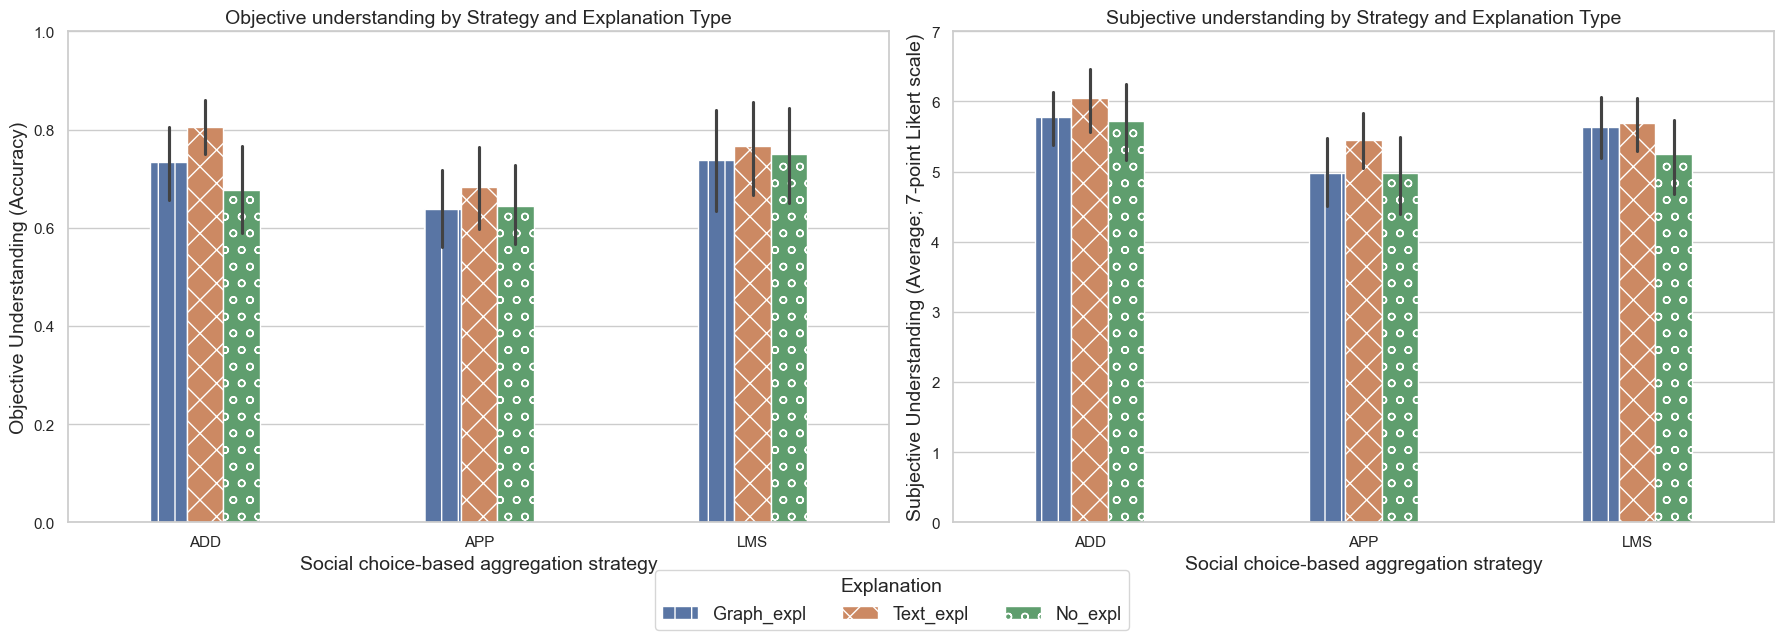

In [81]:
#### FIGURE 2 #######

hatch_patterns = ['|','x', 'o','/', 'o', '.','-'] ### patterns for visibility


fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

## subplot for objective understanding
ax1 = sns.barplot(
    data=df,
    x='Agg',
    y='obj_acc',
    hue='Exp',
    dodge=True,
    width=0.4,
    ax=axes[0]
)
axes[0].set_xlabel('Social choice-based aggregation strategy', fontsize=14)
axes[0].set_ylabel('Objective Understanding (Accuracy)', fontsize=14)
axes[0].set_ylim(0, 1)
axes[0].set_title('Objective understanding by Strategy and Explanation Type', fontsize=14)

## subplot of subjective understanding
ax2 = sns.barplot(
    data=df,
    x='Agg',
    y='subj_score',
    hue='Exp',
    dodge=True,
    width=0.4,
    ax=axes[1]
)
axes[1].set_xlabel('Social choice-based aggregation strategy', fontsize=14)
axes[1].set_ylabel('Subjective Understanding (Average; 7-point Likert scale)', fontsize=14)
axes[1].set_ylim(0, 7)
axes[1].set_title('Subjective understanding by Strategy and Explanation Type', fontsize=14)

## code for patterns and correct legend
handles, labels = axes[0].get_legend_handles_labels()
colors = [h.get_facecolor() for h in handles]  

for ax in [ax1, ax2]:
    for bars, hatch in zip(ax.containers, hatch_patterns):
        for bar in bars:
            bar.set_hatch(hatch)

# Match patterns in bars to legend
legend_patches = [
    mpatches.Patch(facecolor=color,  hatch=hatch, label=label) 
    for color, hatch, label in zip(colors, hatch_patterns, labels)
]

# remove individual legends
axes[0].legend_.remove()
axes[1].legend_.remove()

#shared legend between subplot 1 and subplot 2
fig.legend(handles=legend_patches, title='Explanation', loc='lower center', fontsize=13, title_fontsize=14, ncol=3, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()  

# save figure
plt.savefig('bars-obj-subj-summary.png', dpi=500, bbox_inches='tight')

# plot figure
plt.show()

/var/folders/d4/ddh81b1j0r94c7qm3t38mqcc0000gn/T/ipykernel_92108/1268143998.py:22: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  plot_data['Moment of measurement'] = plot_data['Moment of measurement'].replace({


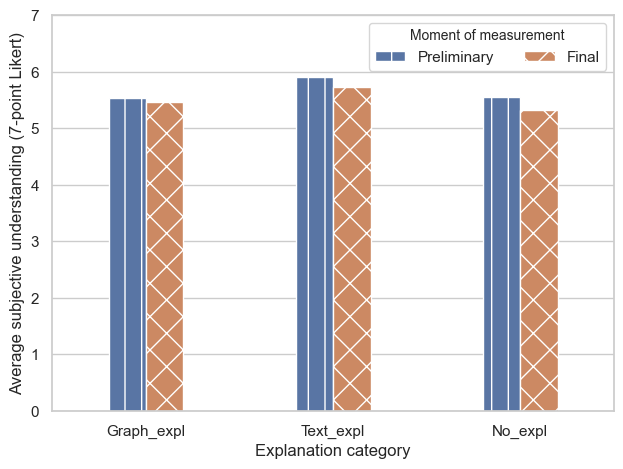

In [68]:
####### Figure 3 ########

# transform data 
df_subj = df[['Agg', 'Exp', 'pre_subj_score', 'subj_score']]

plot_data = pd.melt(
    df_subj,
    id_vars=['Agg', 'Exp'],
    value_vars=['subj_score', 'pre_subj_score'],
    var_name='Moment of measurement',
    value_name='Subjective Understanding'
)

# set logical order for graph
plot_data['Moment of measurement'] = pd.Categorical(
    plot_data['Moment of measurement'],
    categories=['pre_subj_score', 'subj_score'],  # Set desired order for plot (first preliminary, then final score)
    ordered=True
)

# rename for legend
plot_data['Moment of measurement'] = plot_data['Moment of measurement'].replace({
    'pre_subj_score': 'Preliminary',
    'subj_score': 'Final'
})


ax = sns.barplot(
        data=plot_data,
        x='Exp',
        y='Subjective Understanding',
        hue='Moment of measurement',
        dodge=True,  
        errorbar=None,
        width=0.4,
       
    )



plt.xlabel('Explanation category')
plt.ylabel('Average subjective understanding (7-point Likert)', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
colors = [handle.get_facecolor() for handle in handles]  

patterns = ['|','x', '-','/', 'o', '.','-']


for bars, hatch in zip(ax.containers, patterns):
    for bar in bars:
        bar.set_hatch(hatch)

legend_patches = [
    mpatches.Patch(facecolor=color, hatch=hatch, label=label) 
    for color, hatch, label in zip(colors, patterns, labels)
]

plt.legend(handles=legend_patches, fontsize=11, title='Moment of measurement', title_fontsize=10, ncol=3)
plt.tight_layout()
plt.ylim(0,7)
plt.savefig('subj-before-after.png', dpi=500, bbox_inches='tight')

plt.show()

In [69]:
##### Timing #######

### Timing of objective understanding assignments
# per type: (i) model simulation, (ii) counterfactuals, (iii) error detection

times = {f"times_{x}": [] for x in range(7, 13)}
timing_questions = []

for config in range(7, 13): # scenarios 7 to 12 are objective understanding
    col_names = [col for col in df.columns if f"{config}_Page Submit" in col] ## _Page Submit is the timing variable expressing seconds spent on page
    timing_questions.extend(col_names)


for _, row in df.iterrows():
    group = row['Agg']  # Get the participant's group (configurations are categorized by aggregation strategy)
    
    for x in range(7, 13):  # scenarios 7 to 12 are objective understanding
        # Match the timing column for the current group and question number
        timing_name = f"Timing_{group}{x}_Page Submit"
        
        if timing_name in timing_questions:
            times[f"times_{x}"].append(row[timing_name])

for column_name, values in times.items():
    df[column_name] = [float(value) for value in values]

df['modsim'] = df[['times_7', 'times_8']].mean(axis=1)
df['countfac'] = df[['times_9', 'times_10']].mean(axis=1)
df['error'] = df[['times_11', 'times_12']].mean(axis=1)

In [71]:
## ACCURACY PER OBJECTIVE UNDERSTANDING QUESTION TYPE (modsim, countfac, error)
modsim_acc = []
countfac_acc = []
error_acc = []

for _, row in df.iterrows():

    # counter for accuracy
    modsim_correct = 0
    countfac_correct = 0
    error_correct = 0

    if row['Agg'] == 'ADD':
        relevant = Q_filter(correct, '_ADD').set_index('question_id').T
        questions = [
            ('modsim_ADD7', 'modsim_ADD8'),
            ('countfac_ADD9', 'countfac_ADD10'),
            ('error_ADD11', 'error_ADD12')
        ]
    elif row['Agg'] == 'LMS':
        relevant = Q_filter(correct, '_LMS').set_index('question_id').T
        questions = [
            ('modsim_LMS7', 'modsim_LMS8'),
            ('countfac_LMS9', 'countfac_LMS10'),
            ('error_LMS11', 'error_LMS12')
        ]
    elif row['Agg'] == 'APP':
        relevant = Q_filter(correct, '_APP').set_index('question_id').T
        questions = [
            ('modsim_APP7', 'modsim_APP8'),
            ('countfac_APP9', 'countfac_APP10'),
            ('error_APP11', 'error_APP12')
        ]


    # Iterate through question groups and calculate accuracies
    for group, (q1, q2) in zip(['modsim', 'countfac', 'error'], questions):
        correct1 = relevant[q1].response_id # correct response question 1
        correct2 = relevant[q2].response_id # correct response question2
        r1 = row.get(q1, None) #respondent response 1
        r2 = row.get(q2, None) #repondent response 2

        correct_count = 0
        if int(float(r1)) == correct1:
            correct_count += 1
        if int(float(r2)) == correct2:
            correct_count += 1


   
        if group == 'modsim':
            modsim_correct += correct_count
        elif group == 'countfac':
            countfac_correct += correct_count
        elif group == 'error':
            error_correct += correct_count



    # 2 questions per type. Accuracy = correct / 2
    modsim_acc.append(modsim_correct / 2)  
    countfac_acc.append(countfac_correct / 2)  
    error_acc.append(error_correct / 2)  

# add to dataframe
df['modsim_acc'] = modsim_acc
df['countfac_acc'] = countfac_acc
df['error_acc'] = error_acc

In [72]:
#### Table 4 ######

for exp in expl_conditions:
    #model simulation
    mean_temp1 = round(s.mean(df[df.Exp==exp]['modsim_acc']),2)
    sd_temp1 = round(s.stdev(df[df.Exp==exp]['modsim_acc']),2)

    #counterfactual
    mean_temp2 = round(s.mean(df[df.Exp==exp]['countfac_acc']),2)
    sd_temp2 = round(s.stdev(df[df.Exp==exp]['countfac_acc']),2)

    # error detection
    mean_temp3 = round(s.mean(df[df.Exp==exp]['error_acc']),2)
    sd_temp3 = round(s.stdev(df[df.Exp==exp]['error_acc']),2)
    
    ## print table to show results
    table4 = f"""
    {'-'*40}
    # Explanation condition: {exp}
    # Task: Model simulation                        Task: Counterfactual                    Task: Error detection
    # {mean_temp1} ({sd_temp1})                                   {mean_temp2} ({sd_temp2})                             {mean_temp3} ({sd_temp3})

    {'-'*40}
    """
    print(table4)



    ----------------------------------------
    # Explanation condition: No_expl
    # Task: Model simulation                        Task: Counterfactual                    Task: Error detection
    # 0.73 (0.38)                                   0.52 (0.43)                             0.82 (0.31)

    ----------------------------------------
    

    ----------------------------------------
    # Explanation condition: Graph_expl
    # Task: Model simulation                        Task: Counterfactual                    Task: Error detection
    # 0.74 (0.39)                                   0.53 (0.41)                             0.84 (0.25)

    ----------------------------------------
    

    ----------------------------------------
    # Explanation condition: Text_expl
    # Task: Model simulation                        Task: Counterfactual                    Task: Error detection
    # 0.81 (0.31)                                   0.54 (0.43)                             0.

In [73]:
#### Table 5 #####
for exp in expl_conditions:
    #model simulation
    mean_temp1 = round(s.mean(df[df.Exp==exp]['modsim']),2)
    sd_temp1 = round(s.stdev(df[df.Exp==exp]['modsim']),2)

    #counterfactual
    mean_temp2 = round(s.mean(df[df.Exp==exp]['countfac']),2)
    sd_temp2 = round(s.stdev(df[df.Exp==exp]['countfac']),2)

    # error detection
    mean_temp3 = round(s.mean(df[df.Exp==exp]['error']),2)
    sd_temp3 = round(s.stdev(df[df.Exp==exp]['error']),2)
    
    # print table to show results
    table5 = f"""
    {'-'*40}
    # Explanation condition: {exp}
    # Task: Model simulation                        Task: Counterfactual                    Task: Error detection
    # {mean_temp1} ({sd_temp1})                                 {mean_temp2} ({sd_temp2})                          {mean_temp3} ({sd_temp3})

    {'-'*40}
    """
    print(table5)



    ----------------------------------------
    # Explanation condition: No_expl
    # Task: Model simulation                        Task: Counterfactual                    Task: Error detection
    # 51.47 (40.13)                                 113.18 (85.91)                          36.76 (26.38)

    ----------------------------------------
    

    ----------------------------------------
    # Explanation condition: Graph_expl
    # Task: Model simulation                        Task: Counterfactual                    Task: Error detection
    # 48.39 (35.73)                                 111.59 (94.89)                          39.45 (32.24)

    ----------------------------------------
    

    ----------------------------------------
    # Explanation condition: Text_expl
    # Task: Model simulation                        Task: Counterfactual                    Task: Error detection
    # 58.48 (114.17)                                 114.28 (74.01)                       

In [75]:
## Format final dataframe and save it
# Include all relevant columns (accuracies, scores, timing, obj tasks)

df_stats = df[['index','Agg', 'Exp', 'subj_score', 'pre_subj_score','obj_score', 'obj_acc', 'modsim_acc', 'countfac_acc', 'error_acc','times_7','times_8','times_9','times_10','times_11','times_12']]
df_stats.columns = ['ID','Agg', 'Exp', 'subj_score','pre_subj_score', 'obj_score', 'obj_acc','modsim_acc', 'countfac_acc', 'error_acc','times_7','times_8','times_9','times_10','times_11','times_12']
df_stats.to_csv('understanding-data-for-statistics.csv', sep=',')